# Massive Activation Perturbation Test: Token Identity vs. Positional Structure

**Hypothesis under test:** Sun et al. (COLM 2024) claim massive activations (MAs) are
*input-agnostic* — their values stay roughly constant regardless of input content. We test
a stronger, more specific version of this claim: is the MA at position 0 driven by the
**semantic identity** of the token occupying that position, or is it a **structural/positional**
effect that persists even when the position-0 token embedding is replaced by a random
direction of the same norm?

**Design**
1. Generate N random nonsensical sentences (real vocab tokens, no semantic structure), no BOS.
2. Run a baseline forward pass, confirm MAs replicate at position 0 / known channels
   (~788, 1384, 4062 for Llama-3.1-8B), consistent with prior notebook (`01f_*`).
3. Perturb the **position-0 input embedding** with a uniformly random direction on the
   hypersphere of the same norm (full direction randomization, exact norm preservation).
4. Re-run forward pass, compare MA magnitude/location pre- vs. post-perturbation.
5. Control: repeat the identical perturbation at a mid-sequence position instead of
   position 0, to confirm any effect is position-0-specific rather than generic.

**Interpretation:** if MA magnitude survives full direction randomization at fixed norm,
this is strong evidence MAs are structural/positional (input-agnostic in the strong sense),
supporting the confound-check framing (MAs as a control analysis, not a causal driver of
Jacobian spike behavior) rather than the reverse.

No BOS token is prepended anywhere in this notebook — position 0 is the first random
content token, consistent with the `01f_block_jacobian_svd_sweep.ipynb` setup.


## 1. Setup

In [1]:
import os
import random
import json

import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import pandas as pd

MODEL_PATH = "/home/samuel/research/llmattacks/llm-attacks/DIR/Llama-3.1-8B-Instruct"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Device: {DEVICE}, dtype: {DTYPE}")


Device: cuda, dtype: torch.bfloat16


In [2]:

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=DTYPE,
    device_map=DEVICE,
)
model.eval()

VOCAB_SIZE = model.get_input_embeddings().weight.shape[0]
D_MODEL = model.get_input_embeddings().weight.shape[1]
N_LAYERS = model.config.num_hidden_layers

print(f"Vocab size: {VOCAB_SIZE}, d_model: {D_MODEL}, n_layers: {N_LAYERS}")


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Vocab size: 128256, d_model: 4096, n_layers: 32


## 2. Config

Known massive-activation channels and the reference position, carried over from
`01f_block_jacobian_svd_sweep.ipynb`. Adjust if the earlier notebook's findings change.

In [ ]:
N_SAMPLES = 2          # number of random nonsensical sentences
SEQ_LEN_RANGE = (8, 10)  # inclusive, tokens per sentence
PERTURB_POS = 0          # position 0 = first content token (no BOS)

KNOWN_MA_CHANNELS = [788, 1384, 4062]   # from prior notebook, replicated at position 0
MA_RATIO_THRESHOLD = 1000               # "genuine" massive activation threshold (Sun et al. convention)

assert CONTROL_POS < SEQ_LEN_RANGE[0], "control position must be within every sampled sentence"


## 3. Sample random nonsensical sentences

Token IDs are drawn uniformly from the vocabulary, excluding special/reserved tokens
(Llama-3.1's tokenizer reserves a large block of `<|reserved_special_token_*|>` and other
control tokens that would pollute both the "nonsensical sentence" semantics and the
activation statistics).

In [10]:

def get_excluded_token_ids(tokenizer):
    excluded = set(tokenizer.all_special_ids)
    # Sweep the vocab once and flag anything that decodes to a reserved/control-looking
    # token, as a fallback in case all_special_ids doesn't capture every reserved slot.
    for tid in range(tokenizer.vocab_size, len(tokenizer.get_vocab())):
        excluded.add(tid)  # anything beyond base vocab_size is typically added/special
    return excluded

EXCLUDED_IDS = get_excluded_token_ids(tokenizer)
VALID_IDS = np.array([i for i in range(VOCAB_SIZE) if i not in EXCLUDED_IDS])
print(f"Excluded {len(EXCLUDED_IDS)} special/reserved ids; {len(VALID_IDS)} valid ids remain")


Excluded 256 special/reserved ids; 128000 valid ids remain


In [11]:

def sample_random_sentence(rng):
    seq_len = rng.integers(SEQ_LEN_RANGE[0], SEQ_LEN_RANGE[1] + 1)
    token_ids = rng.choice(VALID_IDS, size=seq_len, replace=True).tolist()
    return token_ids

rng = np.random.default_rng(SEED)
samples = [sample_random_sentence(rng) for _ in range(N_SAMPLES)]

# Print decoded token lists for every sample as a sanity check.
print("Decoded samples (sanity check):")
for i, ids in enumerate(samples):
    tokens = tokenizer.convert_ids_to_tokens(ids)
    print(f"[{i:03d}] ids={ids}")
    print(f"      tokens={tokens}")


Decoded samples (sanity check):
[000] ids=[81531, 65425, 34532, 39402, 5244, 9630, 2115, 22434, 104098, 83125]
      tokens=['ĉbegin', 'Ġwag', '.hh', 'ĠStores', 'ĊĊĊĊĊĊ', 'Ġfol', 'Ġfield', 'Hide', 'lub', 'æĸĩç«ł']
[001] ids=[64464, 77649, 124255, 93375, 80930, 69583, 71669, 119689, 35500, 104429]
      tokens=['Justin', '_COOKIE', 'ĠÐ³Ð¾ÑĢÐ¼', 'intelligence', 'Ġtess', 'refund', 'umba', 'æĻĵ', 'ĠkÃ¸', 'ìľ¼ë©°']


## 4. Baseline activation capture

Uses `output_hidden_states=True` (one tensor per layer, including the embedding output)
since we only need raw activation magnitudes here, not Jacobians.

In [12]:
@torch.no_grad()
def run_forward(input_ids=None, inputs_embeds=None):
    """Run a forward pass from either input_ids or inputs_embeds, return hidden_states tuple."""
    if input_ids is not None:
        attention_mask = torch.ones_like(input_ids)
        out = model(input_ids=input_ids, attention_mask=attention_mask,
                     output_hidden_states=True, use_cache=False)
    else:
        attention_mask = torch.ones(inputs_embeds.shape[:2], dtype=torch.long, device=inputs_embeds.device)
        out = model(inputs_embeds=inputs_embeds, attention_mask=attention_mask,
                     output_hidden_states=True, use_cache=False)
    # hidden_states: tuple of (n_layers + 1) tensors, each [batch, seq, d_model]
    return out.hidden_states


def ma_stats_at_position(hidden_states, position, channels=KNOWN_MA_CHANNELS):
    """For each layer, return |activation| at (position, channel) and the layer's median |activation|
    at that position (for ratio computation), plus the layer-wide argmax location."""
    records = []
    for layer_idx, h in enumerate(hidden_states):
        h_pos = h[0, position, :].float()  # [d_model]
        abs_h = h_pos.abs()
        median_abs = abs_h.median().item()
        argmax_dim = int(abs_h.argmax().item())
        argmax_val = abs_h[argmax_dim].item()
        for ch in channels:
            val = abs_h[ch].item()
            ratio = val / median_abs if median_abs > 0 else float("nan")
            records.append({
                "layer": layer_idx, "channel": ch, "abs_activation": val,
                "median_abs": median_abs, "ratio": ratio,
            })
        records.append({
            "layer": layer_idx, "channel": "argmax", "abs_activation": argmax_val,
            "median_abs": median_abs, "ratio": (argmax_val / median_abs if median_abs > 0 else float("nan")),
            "argmax_dim": argmax_dim,
        })
    return records


## Layerwise scan: find where massive activations emerge

Reproduces the depth-wise summary behind Table 1 / Appendix A.4: for each layer, the top-5 |activation| values and
the median |activation|, taken over all $T \times d$ scalar entries. Massive activations should appear as an abrupt
jump in the top-1/top-2 curve after an early layer, and persist until dropping off near the final layers.

In [13]:
def layerwise_scan(token_ids, hidden_states):
    stats = np.zeros((6, len(hidden_states)))  # rows: top1..top5, median
    # SEQ = tokenizer.decode(token_ids)
    for l, h in enumerate(hidden_states):
        feat_abs = h[0].float().abs()  # (T, d)
        flat_sorted, _ = torch.sort(feat_abs.flatten(), descending=True)
        
        stats[:5, l] = flat_sorted[:5].cpu().numpy()
        stats[5, l] = feat_abs.median().item()
        # print(stats[:5, l])

    layer_axis = np.arange(len(hidden_states))  # 0 = embeddings, 1..L = after each decoder layer

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, label in enumerate(["top-1", "top-2", "top-3", "top-4", "top-5"]):
        ax.plot(layer_axis, stats[i], marker="o", markersize=3, label=label)
    ax.plot(layer_axis, stats[5], marker="o", markersize=3, label="median", linestyle="--", color="gray")
    ax.set_xlabel("layer index (0 = embedding output, i = after decoder layer i)")
    ax.set_ylabel("activation magnitude")
    # ax.set_yscale("log")
    # ax.set_title(f"Llama-3.1-8B-Instruct: top-k |activation| vs. layer\nprompt: \"{SEQ}\"")
    ax.set_title(f"Llama-3.1-8B-Instruct: top-k |activation| vs. layer\nToken IDs: \"{token_ids}\"")
    ax.legend()
    plt.tight_layout()
    plt.show()

    best_layer = int(np.argmax(stats[0]))
    print(f"Layer with largest top-1 |activation|: {best_layer} "
        f"(value={stats[0, best_layer]:.1f}, median={stats[5, best_layer]:.3f}, "
        f"ratio={stats[0, best_layer] / max(stats[5, best_layer], 1e-8):.0f}x)")
    return best_layer

## 3D bar plot (reproducing Figure 1 style)

x-axis: feature dimension, y-axis: token position (labeled with decoded tokens), z-axis: activation magnitude.

Plotting all `hidden_size` (4096 or more) bars per token is expensive to render as individual `bar3d` calls, so we
plot every feature dimension but as a single fast `bar3d` batch call (matches the paper's dense "skyline" look).

In [14]:
def plot_3d_feat(h, tokens_decoded, layer_id, model_name, savepath=None, elev=25, azim=-60):
    """h: (T, d) tensor (already moved to CPU, float)."""
    feat_abs = h.float().abs().cpu().numpy()
    T, d = feat_abs.shape

    fig = plt.figure(figsize=(11, 7))
    ax = fig.add_subplot(111, projection="3d")

    xs = np.arange(d)
    dx = np.ones(d) * 1.0
    dy = np.ones(d) * 0.6
 
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, T))

    for t in range(T):
        ys = np.full(d, t)
        zs = np.zeros(d)
        dz = feat_abs[t]
        ax.bar3d(xs, ys, zs, dx, dy, dz, color=colors[t], shade=True, edgecolor="none", alpha=0.9)

    ax.set_xlabel("feature dimension")
    ax.set_ylabel("token position")
    ax.set_zlabel("activation magnitude")
    ax.set_yticks(np.arange(T))
    ax.set_yticklabels(tokens_decoded)
    ax.set_title(f"{model_name} — layer {layer_id}\nmassive activations stand out as isolated spikes")
    ax.view_init(elev=elev, azim=azim)

    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
        print(f"saved to {savepath}")
    plt.show()

# plot_3d_feat(
#     h_l.cpu(),
#     tokens_decoded,
#     LAYER_ID,
#     "Llama-3.1-8B-Instruct",
#     savepath="llama31_8b_instruct_massive_activations_layer%d.png" % LAYER_ID,
# )

## Identify the massive-activation (token, feature-dim) coordinates

Using the paper's criterion: $|h_\ell[t,i]| > 100$ **and** $\geq \sim 1000\times$ the layer's median magnitude.

In [15]:
def find_massive_activations(h, abs_thresh=100.0, ratio_thresh=1000.0):
    """h: (T, d) tensor for a single layer. Returns list of (token_idx, feat_idx, value)."""
    feat_abs = h.float().abs()
    med = feat_abs.median().item()
    mask = (feat_abs > abs_thresh) & (feat_abs > ratio_thresh * med)
    idxs = torch.nonzero(mask, as_tuple=False)
    results = [(int(t), int(i), feat_abs[t, i].item()) for t, i in idxs]
    results.sort(key=lambda r: -r[2])
    return results, med


## Main run 

In [ ]:
assert len(samples) > 0, "samples is empty — run the sampling cell in Section 3 first"
for i, ids in enumerate(samples):
    input_ids = torch.tensor([ids], device=DEVICE)
    hidden_states = run_forward(input_ids=input_ids)
    # tokens = tokenizer.convert_ids_to_tokens(ids)
    # print(f"[{i:03d}] ids={ids}")
    # print(f"      tokens={tokens}")
    best_layer = layerwise_scan(ids, hidden_states)
    LAYER_ID = best_layer
    tokens_decoded = tokenizer.convert_ids_to_tokens(ids)
    # LAYER_ID defaults to best_layer from the scan above; override manually to inspect a
    # specific layer instead.
    h_l = hidden_states[LAYER_ID][0]  # (T, d)
    plot_3d_feat(
        h_l,
        tokens_decoded,
        LAYER_ID,
        "Llama-3.1-8B-Instruct",
        savepath="llama31_8b_instruct_massive_activations_layer%d.png" % LAYER_ID,
    )

    mas, layer_median = find_massive_activations(h_l)
    print(f"Layer {LAYER_ID} — median |activation| = {layer_median:.4f}")
    print(f"Found {len(mas)} massive activation(s):")
    for t, i, v in mas:
        print(f"  token[{t}]=\"{tokens_decoded[t]}\"  feature_dim={i}  |activation|={v:.1f}")


In [ ]:
# # Sanity check: do known channels replicate MA behaviour at position 0 across random samples?
# summary = (
#     baseline_df[baseline_df["channel"].isin(KNOWN_MA_CHANNELS)]
#     .groupby("channel")["ratio"]
#     .agg(["mean", "median", "min", "max"])
# )
# print("Baseline ratio stats at position 0, known channels, across all samples:")
# print(summary)

# frac_genuine = (
#     baseline_df[baseline_df["channel"].isin(KNOWN_MA_CHANNELS)]
#     .groupby("channel")["ratio"]
#     .apply(lambda s: (s > MA_RATIO_THRESHOLD).mean())
# )
# print("\\nFraction of samples exceeding MA_RATIO_THRESHOLD, per channel:")
# print(frac_genuine)


## 5. Norm-preserving perturbation

For the token at the target position, replace its input embedding with a uniformly random
point on the hypersphere of the same norm:

$$e' = \|e\| \cdot \frac{n}{\|n\|}, \quad n \sim \mathcal{N}(0, I_d)$$

This is the full-randomization extreme case: in ~4096-d space, `e'` has expected cosine
similarity ≈ 0 with the original embedding `e`, while `||e'|| = ||e||` exactly.

In [ ]:
# def perturb_embedding_random_direction(embedding_row, generator):
#     """embedding_row: [d_model] tensor. Returns a new tensor with same norm, random direction."""
#     d = embedding_row.shape[0]
#     noise = torch.randn(d, generator=generator, device=embedding_row.device, dtype=torch.float32)
#     unit_noise = noise / noise.norm()
#     new_row = unit_noise * embedding_row.float().norm()
#     return new_row.to(embedding_row.dtype)

def perturb_embedding_random_direction(embedding_row, generator):
    """embedding_row: [d_model] tensor. Returns a new tensor with same norm, random direction."""
    d = embedding_row.shape[0]
    noise = torch.randn(d, generator=generator, device=embedding_row.device, dtype=torch.float32)
    unit_noise = noise / noise.norm()
    new_row = unit_noise * embedding_row.float().norm()

    assert torch.allclose(
        new_row.norm(), embedding_row.float().norm(), rtol=1e-5, atol=1e-6
    ), f"norm mismatch: new={new_row.norm().item():.6f}, orig={embedding_row.float().norm().item():.6f}"

    return new_row.to(embedding_row.dtype)


def build_inputs_embeds_with_perturbation(input_ids, perturb_position, torch_gen):
    """Return inputs_embeds [1, seq, d_model] with the token at perturb_position replaced
    by a random-direction, same-norm embedding."""
    embed_layer = model.get_input_embeddings()
    with torch.no_grad():
        base_embeds = embed_layer(input_ids).clone()  # [1, seq, d_model]
        original_row = base_embeds[0, perturb_position, :]
        perturbed_row = perturb_embedding_random_direction(original_row, torch_gen)
        base_embeds[0, perturb_position, :] = perturbed_row
    return base_embeds


def build_inputs_embeds_no_perturbation(input_ids):
    """Return inputs_embeds [1, seq, d_model] with the token at perturb_position replaced
    by a random-direction, same-norm embedding."""
    embed_layer = model.get_input_embeddings()
    with torch.no_grad():
        base_embeds = embed_layer(input_ids).clone()  # [1, seq, d_model]
    return base_embeds


# Fresh, non-reproducible seed for the perturbation generator (independent of the
# fixed SEED above, which only controls sentence sampling) — each run picks a
# different random direction.
PERTURB_SEED = int.from_bytes(os.urandom(4), "big")
torch_gen = torch.Generator(device=DEVICE)
torch_gen.manual_seed(PERTURB_SEED)
print(f"torch_gen seeded with PERTURB_SEED={PERTURB_SEED}")


In [ ]:
# Representative embedding norm: median over the full vocabulary's row norms.
# The specific token/vector attaining it is irrelevant — this is just a robust
# (outlier-resistant) scalar summary of "how big is a typical embedding vector".
embedding_matrix = model.get_input_embeddings().weight.detach().float()
embedding_row_norms = embedding_matrix.norm(dim=1)  # [VOCAB_SIZE]
median_embedding_norm = embedding_row_norms.median().item()

print(f"Embedding row norms — min={embedding_row_norms.min().item():.4f}  "
      f"median={median_embedding_norm:.4f}  max={embedding_row_norms.max().item():.4f}")


## 6. Perturbation experiment — position 0 (treatment) and mid-sequence (control)

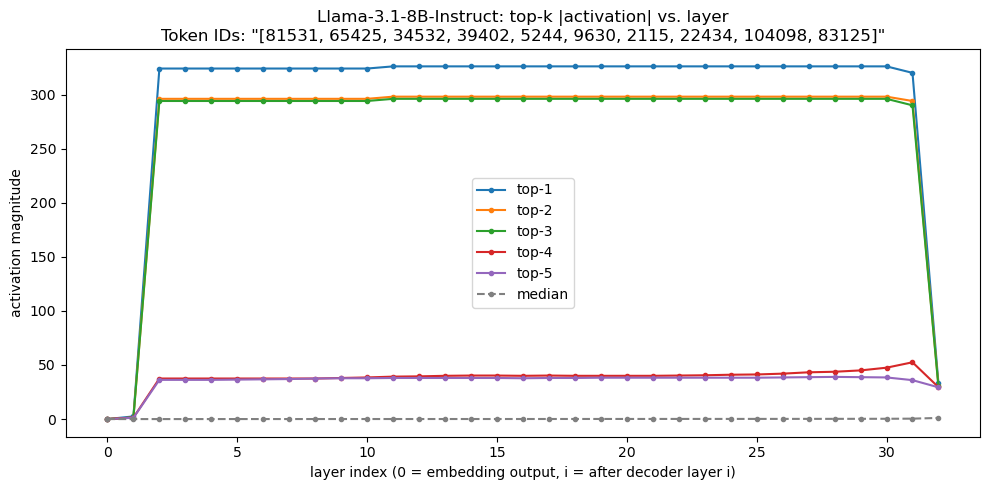

Layer with largest top-1 |activation|: 11 (value=326.0, median=0.066, ratio=4946x)


/tmp/ipykernel_143786/985653031.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


saved to llama31_8b_instruct_massive_activations_layer11.png


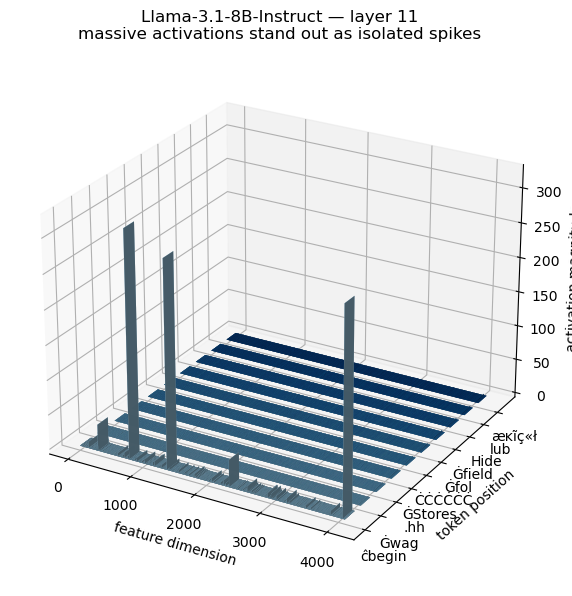

Layer 11 — median |activation| = 0.0659
Found 3 massive activation(s):
  token[0]="ĉbegin"  feature_dim=788  |activation|=326.0
  token[0]="ĉbegin"  feature_dim=1384  |activation|=298.0
  token[0]="ĉbegin"  feature_dim=4062  |activation|=296.0


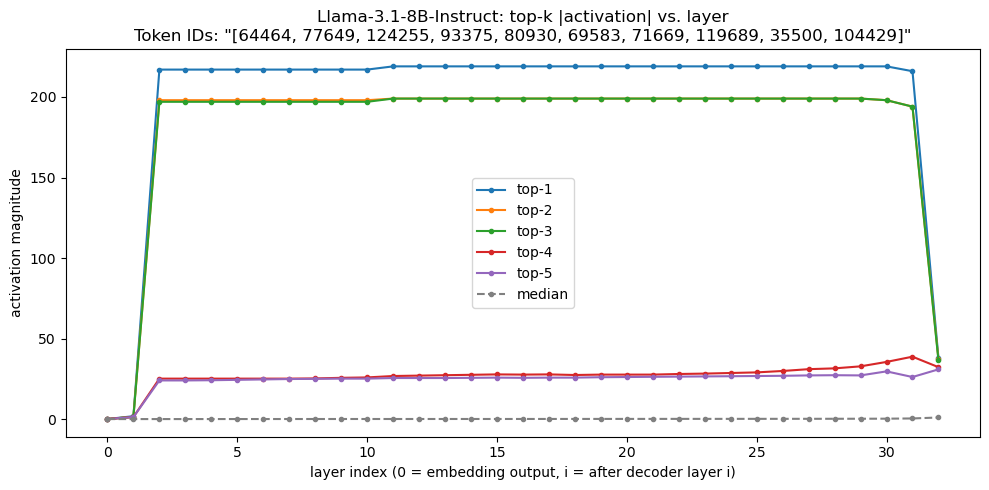

Layer with largest top-1 |activation|: 11 (value=219.0, median=0.063, ratio=3450x)
saved to llama31_8b_instruct_massive_activations_layer11.png


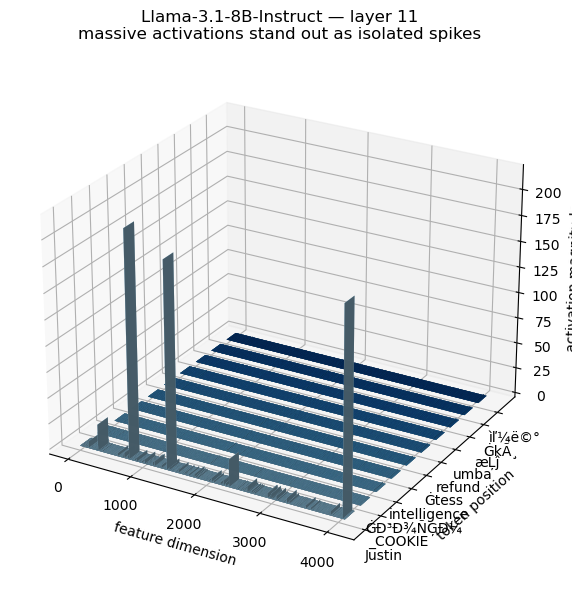

Layer 11 — median |activation| = 0.0635
Found 3 massive activation(s):
  token[0]="Justin"  feature_dim=788  |activation|=219.0
  token[0]="Justin"  feature_dim=1384  |activation|=199.0
  token[0]="Justin"  feature_dim=4062  |activation|=199.0


In [18]:
# No perturbation
for i, ids in enumerate(samples):
    input_ids = torch.tensor([ids], device=DEVICE)
    inputs_embeds = build_inputs_embeds_no_perturbation(input_ids)
    hidden_states = run_forward(inputs_embeds=inputs_embeds)
    ## Visualize
    best_layer = layerwise_scan(ids, hidden_states)
    LAYER_ID = best_layer
    tokens_decoded = tokenizer.convert_ids_to_tokens(ids)
    # LAYER_ID defaults to best_layer from the scan above; override manually to inspect a
    # specific layer instead.
    h_l = hidden_states[LAYER_ID][0]  # (T, d)
    plot_3d_feat(
        h_l,
        tokens_decoded,
        LAYER_ID,
        "Llama-3.1-8B-Instruct",
        savepath="llama31_8b_instruct_massive_activations_layer%d.png" % LAYER_ID,
    )

    mas, layer_median = find_massive_activations(h_l)
    print(f"Layer {LAYER_ID} — median |activation| = {layer_median:.4f}")
    print(f"Found {len(mas)} massive activation(s):")
    for t, i, v in mas:
        print(f"  token[{t}]=\"{tokens_decoded[t]}\"  feature_dim={i}  |activation|={v:.1f}")
    ## Visualize

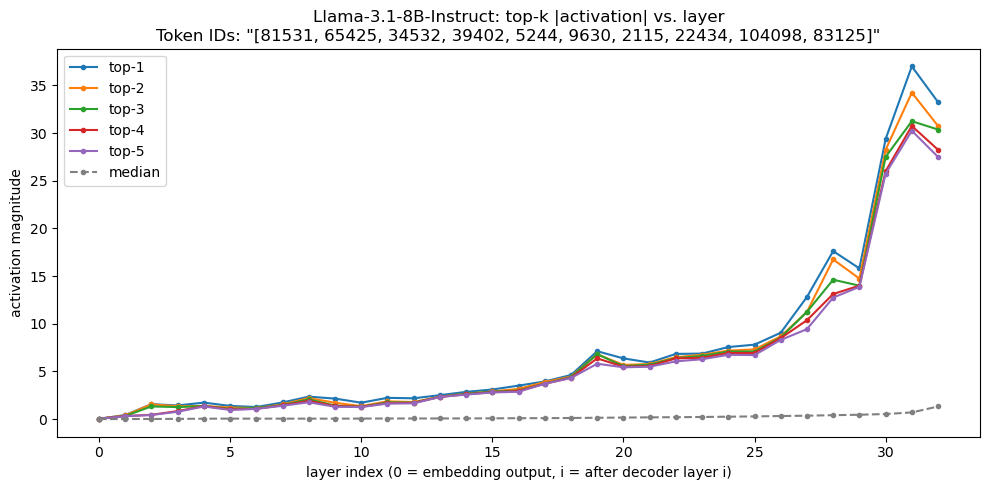

Layer with largest top-1 |activation|: 31 (value=37.0, median=0.703, ratio=53x)


/tmp/ipykernel_143786/985653031.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


saved to llama31_8b_instruct_massive_activations_layer31.png


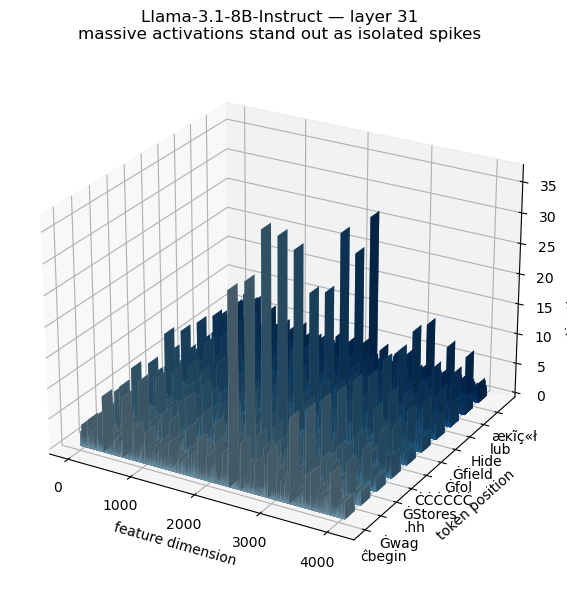

Layer 31 — median |activation| = 0.7031
Found 0 massive activation(s):


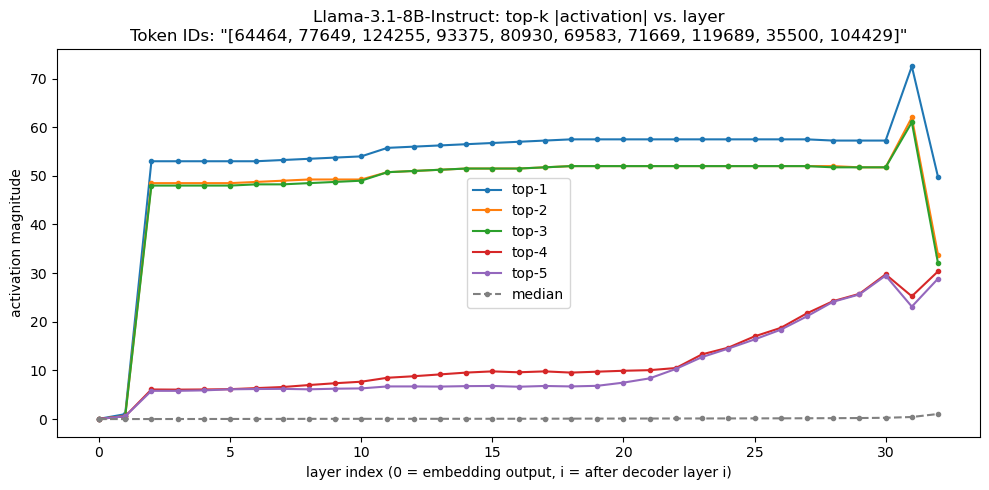

Layer with largest top-1 |activation|: 31 (value=72.5, median=0.436, ratio=166x)
saved to llama31_8b_instruct_massive_activations_layer31.png


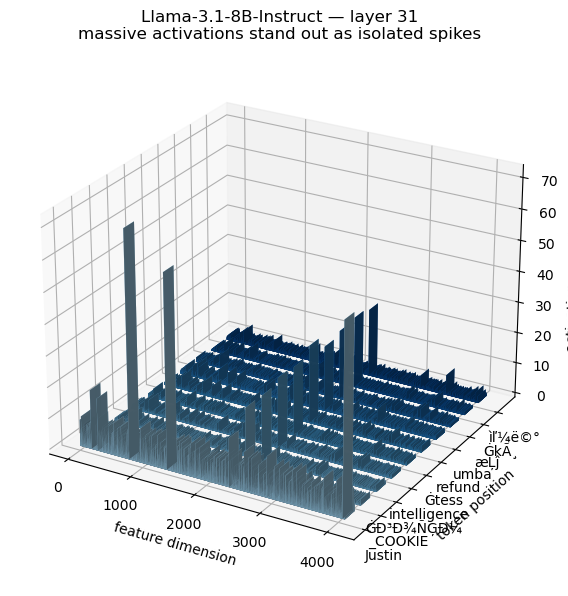

Layer 31 — median |activation| = 0.4355
Found 0 massive activation(s):


In [19]:
def run_perturbation_condition(samples, perturb_position, stage_name, torch_gen):
    records = []
    for i, ids in enumerate(samples):
        input_ids = torch.tensor([ids], device=DEVICE)
        inputs_embeds = build_inputs_embeds_with_perturbation(input_ids, perturb_position, torch_gen)
        hidden_states = run_forward(inputs_embeds=inputs_embeds)
        ## Visualize
        best_layer = layerwise_scan(ids, hidden_states)
        LAYER_ID = best_layer
        tokens_decoded = tokenizer.convert_ids_to_tokens(ids)
        # LAYER_ID defaults to best_layer from the scan above; override manually to inspect a
        # specific layer instead.
        h_l = hidden_states[LAYER_ID][0]  # (T, d)
        plot_3d_feat(
            h_l,
            tokens_decoded,
            LAYER_ID,
            "Llama-3.1-8B-Instruct",
            savepath="llama31_8b_instruct_massive_activations_layer%d.png" % LAYER_ID,
        )

        mas, layer_median = find_massive_activations(h_l)
        print(f"Layer {LAYER_ID} — median |activation| = {layer_median:.4f}")
        print(f"Found {len(mas)} massive activation(s):")
        for t, i, v in mas:
            print(f"  token[{t}]=\"{tokens_decoded[t]}\"  feature_dim={i}  |activation|={v:.1f}")
        ## Visualize
        recs = ma_stats_at_position(hidden_states, perturb_position)
        for r in recs:
            r["sample"] = i
            r["stage"] = stage_name
        records.extend(recs)
    return records

treatment_records = run_perturbation_condition(samples, PERTURB_POS, "perturbed_pos0", torch_gen)

# treatment_df = pd.DataFrame(treatment_records)


## Additional Codes

In [20]:
OUTPUT_DIR = "layerwise_tensors"
os.makedirs(OUTPUT_DIR, exist_ok=True)

embedding_matrix = model.get_input_embeddings().weight.detach().float().cpu().numpy()
embedding_path = os.path.join(OUTPUT_DIR, "embedding_matrix.npy")
np.save(embedding_path, embedding_matrix)
print(f"Saved embedding matrix {embedding_matrix.shape} to {embedding_path}")


Saved embedding matrix (128256, 4096) to layerwise_tensors/embedding_matrix.npy
